# MODEL DEVELOPMENT


In [45]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, f1_score, roc_auc_score, 
                            precision_score, recall_score, accuracy_score,
                            confusion_matrix, roc_curve, precision_recall_curve)
import xgboost as xgb
from scipy.stats import ttest_ind
import json
import os
import warnings
import time

warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print(" All libraries imported successfully")

# Load the dataset
df_model= pd.read_csv('../../data/processed/modeling_dataset_25k.csv')
print(f" Dataset loaded successfully with shape: {df_model.shape}")


 All libraries imported successfully
 Dataset loaded successfully with shape: (25000, 33)



### Feature Engineering Pipeline 

Objective: Transform raw data into model-ready features


In [46]:

print(f"\nStarting Dataset:")
print(f"Samples: {len(df_model):,}")
print(f"Original Features: {df_model.shape[1]}")


# STEP 1: Log Transformations (to fix skewness)
print("STEP 1: LOG TRANSFORMATIONS")

skewed_features = ['views', 'likes', 'comments', 'shares', 'saves']
for col in skewed_features:
    if col in df_model.columns:
        df_model[f'{col}_log'] = np.log1p(df_model[col])
        print(f" Created {col}_log")


# STEP 2: Engagement Rate Features (quality not quantity)
print("STEP 2: ENGAGEMENT RATES")

df_model['like_rate'] = df_model['likes'] / (df_model['views'] + 1)
df_model['comment_rate'] = df_model['comments'] / (df_model['views'] + 1)
df_model['share_rate'] = df_model['shares'] / (df_model['views'] + 1)
print(" Created like_rate, comment_rate, share_rate")


# STEP 3: Temporal Features (optimal posting times)
print("STEP 3: TEMPORAL FEATURES")

# Convert day names to numbers if needed
if df_model['posting_day'].dtype == 'object':
    day_mapping = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 
                   'Friday': 4, 'Saturday': 5, 'Sunday': 6}
    df_model['posting_day'] = df_model['posting_day'].map(day_mapping)
    
    # Check for any unmapped values
    if df_model['posting_day'].isnull().any():
        print(f"Warning: Found {df_model['posting_day'].isnull().sum()} unmapped day values")
        # Fill with most common day (weekday = 2 for Wednesday)
        df_model['posting_day'].fillna(2, inplace=True)

df_model['is_weekend'] = df_model['posting_day'].isin([5, 6]).astype(int)
df_model['is_peak_hour'] = df_model['posting_hour'].isin([18, 19, 20]).astype(int)
df_model['is_evening'] = (df_model['posting_hour'] >= 18).astype(int)
print(" Created is_weekend, is_peak_hour, is_evening")


# STEP 4: Content Optimisation Features (EDA findings)

print("STEP 4: CONTENT OPTIMISATION")


df_model['optimal_hashtag_range'] = df_model['hashtag_count'].between(5, 10).astype(int)
df_model['has_short_caption'] = (df_model['caption_length'] < 50).astype(int)
df_model['has_optimal_caption'] = df_model['caption_length'].between(100, 150).astype(int)
df_model['has_long_caption'] = (df_model['caption_length'] > 200).astype(int)
print("Created optimal_hashtag_range, caption length features")


# STEP 5: Encode Categorical Variables
print("STEP 5: CATEGORICAL ENCODING")


# Platform (One-Hot -- Binary columns for each platform)
platform_encoded = pd.get_dummies(df_model['platform'], prefix='platform', dtype=int)
df_model = pd.concat([df_model, platform_encoded], axis=1)
print(f" Platform encoded: {list(platform_encoded.columns)}")

#  Trend Label (One-Hot)
trend_encoded = pd.get_dummies(df_model['trend_label'], prefix='trend', dtype=int)
df_model = pd.concat([df_model, trend_encoded], axis=1)
print(f" Trend encoded: {list(trend_encoded.columns)}")

# Category (Target Encoding)
category_encoding = df_model.groupby('category')['engagement_binary'].mean()
df_model['category_encoded'] = df_model['category'].map(category_encoding)
print(f" Category target encoded")


# STEP 6: Final Feature Selection
print("STEP 6: FINAL FEATURE LIST")


selected_features = [
    # Trend features (CORE HYPOTHESIS)
    'has_trend',
    'trend_rising', 'trend_seasonal', 'trend_stable', 'trend_declining',
    
    # Temporal features
    'posting_hour', 'posting_day', 'posting_month',
    'is_peak_hour', 'is_weekend', 'is_evening',
    
    # Content features
    'caption_length', 'hashtag_count', 'duration_sec',
    'optimal_hashtag_range', 'has_optimal_caption', 
    'has_short_caption', 'has_long_caption',
    
    
    # Platform (one-hot)
    'platform_tiktok', 'platform_instagram', 'platform_youtube',
    
    # Category (target encoded)
    'category_encoded'
]

print(f"Selected {len(selected_features)} features")

# Verify all features exist
missing = [f for f in selected_features if f not in df_model.columns]
if missing:
    print(f"  Missing: {missing}")
else:
    print(f"All features present!")


# STEP 7: Data Quality Check
print("STEP 7: QUALITY CHECKS")


# Missing values
missing_count = df_model[selected_features].isnull().sum().sum()
print(f"Missing values: {missing_count}")

# If there are missing values, show which features and fill them
if missing_count > 0:
    missing_by_feature = df_model[selected_features].isnull().sum()
    missing_by_feature = missing_by_feature[missing_by_feature > 0]
    print("\nFeatures with missing values:")
    for feat, count in missing_by_feature.items():
        print(f"  {feat}: {count}")
    print("\nFilling missing values with 0...")
    df_model[selected_features] = df_model[selected_features].fillna(0)
    print("Missing values filled!")

# Infinite values
inf_count = np.isinf(df_model[selected_features].select_dtypes(include=[np.number])).sum().sum()
print(f"Infinite values: {inf_count}")

if missing_count == 0 and inf_count == 0:
    print("Data quality: PASSED")
elif missing_count > 0:
    print("Data quality: FIXED (NaN values filled)")


# STEP 8: Save Configuration
print("STEP 8: SAVE CONFIGURATION")
os.makedirs('../../models/', exist_ok=True)

feature_config = {
    'selected_features': selected_features,
    'feature_count': len(selected_features),
    'date': '2026-03-03',
    'dataset_size': len(df_model),
    'target': 'engagement_binary'
}
with open('../../models/feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

print("Configuration saved to models/feature_config.json")


print(f"\nFeature Engineering Summary:")
print(f"   Original features:    {df_model.shape[1] - len(selected_features)}")
print(f"   Engineered features:  {len(selected_features)}")
print(f"   Dataset size:         {len(df_model):,} samples")
print(f"   Target variable:      engagement_binary")
print(f"   High engagement:      {df_model['engagement_binary'].sum():,} ({df_model['engagement_binary'].mean()*100:.1f}%)")



Starting Dataset:
Samples: 25,000
Original Features: 33
STEP 1: LOG TRANSFORMATIONS
 Created views_log
 Created likes_log
 Created comments_log
 Created shares_log
 Created saves_log
STEP 2: ENGAGEMENT RATES
 Created like_rate, comment_rate, share_rate
STEP 3: TEMPORAL FEATURES
 Created is_weekend, is_peak_hour, is_evening
STEP 4: CONTENT OPTIMISATION
Created optimal_hashtag_range, caption length features
STEP 5: CATEGORICAL ENCODING
 Platform encoded: ['platform_instagram', 'platform_tiktok', 'platform_youtube']
 Trend encoded: ['trend_declining', 'trend_rising', 'trend_seasonal', 'trend_stable']
 Category target encoded
STEP 6: FINAL FEATURE LIST
Selected 22 features
All features present!
STEP 7: QUALITY CHECKS
Missing values: 9093

Features with missing values:
  duration_sec: 9093

Filling missing values with 0...
Missing values filled!
Infinite values: 0
Data quality: FIXED (NaN values filled)
STEP 8: SAVE CONFIGURATION
Configuration saved to models/feature_config.json

Feature E

### Train-Test-Validation Split (70-15-15)

In [47]:

print("TRAIN-TEST-VALIDATION SPLIT")

# Prepare features and target
X = df_model[selected_features]
y = df_model['engagement_binary']

print(f"\nTotal dataset: {len(X):,} samples")
print(f"Features: {len(selected_features)}")
print(f"Target: engagement_binary")

# First split: 70% train, 30% temp (will become val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    stratify=y, 
    random_state=42
)

# Second split: Split temp into 50/50 (each becomes 15% of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.50, 
    stratify=y_temp, 
    random_state=42
)


# Verify Class Distributions
print("CLASS DISTRIBUTION (High Engagement %)")

train_high_pct = y_train.mean() * 100
val_high_pct = y_val.mean() * 100
test_high_pct = y_test.mean() * 100

print(f"Train: {len(y_train):>6,} samples | High: {train_high_pct:.1f}% | Low: {100-train_high_pct:.1f}%")
print(f"Val:   {len(y_val):>6,} samples | High: {val_high_pct:.1f}% | Low: {100-val_high_pct:.1f}%")
print(f"Test:  {len(y_test):>6,} samples | High: {test_high_pct:.1f}% | Low: {100-test_high_pct:.1f}%")


# Success Check
print("VALIDATION CHECKS")

# Check 1: Sizes are correct
expected_train = int(0.70 * len(X))
expected_val = int(0.15 * len(X))
expected_test = int(0.15 * len(X))

size_check = (
    abs(len(X_train) - expected_train) <= 10 and
    abs(len(X_val) - expected_val) <= 10 and
    abs(len(X_test) - expected_test) <= 10
)

print(f"Split sizes correct (70/15/15): {'PASS' if size_check else 'FAIL'}")

# Check 2: Class balance maintained (within 2% of original)
original_high_pct = y.mean() * 100
balance_check = (
    abs(train_high_pct - original_high_pct) < 2 and
    abs(val_high_pct - original_high_pct) < 2 and
    abs(test_high_pct - original_high_pct) < 2
)

print(f"Stratification maintained: {'PASS' if balance_check else 'FAIL'}")

# Check 3: No data overlap
overlap_check = (
    len(set(X_train.index) & set(X_val.index)) == 0 and
    len(set(X_train.index) & set(X_test.index)) == 0 and
    len(set(X_val.index) & set(X_test.index)) == 0
)

print(f"No data leakage (no overlap): {' PASS' if overlap_check else 'FAIL'}")

if size_check and balance_check and overlap_check:

    print("TASK COMPLETE!")

else:
    print("\nome checks failed - review splits before proceeding")

TRAIN-TEST-VALIDATION SPLIT

Total dataset: 25,000 samples
Features: 22
Target: engagement_binary
CLASS DISTRIBUTION (High Engagement %)
Train: 17,500 samples | High: 78.1% | Low: 21.9%
Val:    3,750 samples | High: 78.1% | Low: 21.9%
Test:   3,750 samples | High: 78.1% | Low: 21.9%
VALIDATION CHECKS
Split sizes correct (70/15/15): PASS
Stratification maintained: PASS
No data leakage (no overlap):  PASS
TASK COMPLETE!


### Baseline Model (Logistic Regression)
Objective: Establish baseline performance with simple model.

In [48]:

print("BASELINE MODEL - LOGISTIC REGRESSION")


# Train baseline model
print("\nTraining baseline model...")
start_time = time.time()

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)

training_time_lr = time.time() - start_time
print(f"Training completed in {training_time_lr:.2f} seconds")


# Make Predictions
print("\nMaking predictions on validation set...")
y_val_pred = baseline.predict(X_val)
y_val_proba = baseline.predict_proba(X_val)[:, 1]


# Performance Metrics
print("VALIDATION PERFORMANCE METRICS")


f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_proba)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
accuracy = accuracy_score(y_val, y_val_pred)

print(f"\nF1 Score:       {f1:.4f}")
print(f"ROC-AUC:        {roc_auc:.4f}")
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"Accuracy:       {accuracy:.4f}")

print("\n" + "-"*70)
print("CLASSIFICATION REPORT")
print("-"*70)
print(classification_report(y_val, y_val_pred, 
                           target_names=['Low Engagement', 'High Engagement']))



# Feature Importance Analysis
print("\n" + "="*70)
print("FEATURE IMPORTANCE (Top 10 by Coefficient Magnitude)")
print("="*70)

coef_df = pd.DataFrame({
    'feature': selected_features,
    'coefficient': baseline.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nTop 10 Most Important Features:")
print(coef_df.head(10).to_string(index=False))

# Check if has_trend is in top 10 (for hypothesis validation)
has_trend_rank = coef_df.reset_index(drop=True).index[coef_df['feature'] == 'has_trend'].tolist()
if has_trend_rank:
    rank = has_trend_rank[0] + 1
    print(f"\n'has_trend' ranked #{rank} out of {len(selected_features)} features")


# Success Criteria Check
criteria = {
    f"F1 Score ≥ 0.70": f1 >= 0.70,
    f"ROC-AUC ≥ 0.75": roc_auc >= 0.75,
    f"Precision ≥ 0.70": precision >= 0.70,
    f"Recall ≥ 0.70": recall >= 0.70,
    f"Training time < 60s": training_time_lr < 60
}

for criterion, passed in criteria.items():
    status = " PASS" if passed else " FAIL"
    print(f"{criterion:<30} {status}")

all_passed = all(criteria.values())


# Final Summary
if all_passed:
    print("\n" + "="*70)
    print(" TASK 1c COMPLETE!")
    print("="*70)
    print(f"\nBaseline Performance Summary:")
    print(f"F1 Score:      {f1:.4f}")
    print(f"ROC-AUC:       {roc_auc:.4f}")
    print(f"Precision:     {precision:.4f}")
    print(f"Recall:        {recall:.4f}")
    print(f"Training time: {training_time_lr:.2f}s")
else:
    print("\n  Some criteria not met - review performance before proceeding")

BASELINE MODEL - LOGISTIC REGRESSION

Training baseline model...
Training completed in 1.40 seconds

Making predictions on validation set...
VALIDATION PERFORMANCE METRICS

F1 Score:       0.8818
ROC-AUC:        0.8860
Precision:      0.8539
Recall:         0.9116
Accuracy:       0.8091

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
                 precision    recall  f1-score   support

 Low Engagement       0.58      0.44      0.50       821
High Engagement       0.85      0.91      0.88      2929

       accuracy                           0.81      3750
      macro avg       0.72      0.68      0.69      3750
   weighted avg       0.79      0.81      0.80      3750


FEATURE IMPORTANCE (Top 10 by Coefficient Magnitude)

Top 10 Most Important Features:
           feature  coefficient
   trend_declining     4.965426
      trend_stable     4.937187
         has_trend 

In [49]:

# RANDOM FOREST MODEL

print("RANDOM FOREST MODEL")


# Hyperparameter Grid Search
print("\nSetting up hyperparameter grid search...")

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None]
}

print(f"Parameter combinations to test: {3 * 4 * 3 * 2} = 72")
print("This will take 1-3 minutes...")

# Initialize Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train with grid search
print("\nTraining Random Forest with GridSearchCV...")
start_time = time.time()

grid_search.fit(X_train, y_train)

training_time_rf = time.time() - start_time
print(f"\nGrid search completed in {training_time_rf:.2f} seconds")


# Best Model Analysis
print("BEST HYPERPARAMETERS")

best_params = grid_search.best_params_
for param, value in best_params.items():
    print(f"{param}: {value}")

print(f"\nBest cross-validation F1 score: {grid_search.best_score_:.4f}")

# Get best model
rf_best = grid_search.best_estimator_


# Validation Performance
print("VALIDATION PERFORMANCE METRICS")


# Make predictions
y_val_pred_rf = rf_best.predict(X_val)
y_val_proba_rf = rf_best.predict_proba(X_val)[:, 1]

# Calculate metrics
f1_rf = f1_score(y_val, y_val_pred_rf)
roc_auc_rf = roc_auc_score(y_val, y_val_proba_rf)
precision_rf = precision_score(y_val, y_val_pred_rf)
recall_rf = recall_score(y_val, y_val_pred_rf)
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"\nF1 Score:       {f1_rf:.4f}")
print(f"ROC-AUC:        {roc_auc_rf:.4f}")
print(f"Precision:      {precision_rf:.4f}")
print(f"Recall:         {recall_rf:.4f}")
print(f"Accuracy:       {accuracy_rf:.4f}")

print("\n" + "-"*70)
print("CLASSIFICATION REPORT")
print("-"*70)
print(classification_report(y_val, y_val_pred_rf, 
                           target_names=['Low Engagement', 'High Engagement']))



# Feature Importance Analysis
print("FEATURE IMPORTANCE (Top 10)")

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Check has_trend ranking
has_trend_rank_rf = feature_importance.reset_index(drop=True).index[
    feature_importance['feature'] == 'has_trend'
].tolist()

if has_trend_rank_rf:
    rank_rf = has_trend_rank_rf[0] + 1
    print(f"\n'has_trend' ranked #{rank_rf} out of {len(selected_features)} features")
    
    if rank_rf <= 5:
        print("Hypothesis validation: 'has_trend' is in TOP 5!")
    else:
        print(f" 'has_trend' ranked #{rank_rf} (target: top 5)")



# Comparison to Baseline
print("COMPARISON TO BASELINE (LOGISTIC REGRESSION)")

comparison = pd.DataFrame({
    'Metric': ['F1 Score', 'ROC-AUC', 'Precision', 'Recall', 'Accuracy'],
    'Logistic Regression': [f1, roc_auc, precision, recall, accuracy],
    'Random Forest': [f1_rf, roc_auc_rf, precision_rf, recall_rf, accuracy_rf],
    'Improvement': [
        f1_rf - f1,
        roc_auc_rf - roc_auc,
        precision_rf - precision,
        recall_rf - recall,
        accuracy_rf - accuracy
    ]
})

print("\n" + comparison.to_string(index=False))

improvement = f1_rf - f1
improvement_pct = (improvement / f1) * 100

print(f"\nF1 Score Improvement: {improvement:+.4f} ({improvement_pct:+.2f}%)")

if f1_rf > f1:
    print("Random Forest OUTPERFORMS baseline")
else:
    print("Random Forest did not beat baseline")


# Success Criteria Check
print("SUCCESS CRITERIA CHECK")

criteria_rf = {
    "F1 Score > Baseline": f1_rf > f1,
    "F1 Score ≥ 0.70": f1_rf >= 0.70,
    "ROC-AUC ≥ 0.75": roc_auc_rf >= 0.75,
    "Training time < 180s": training_time_rf < 180
}

for criterion, passed in criteria_rf.items():
    status = "PASS" if passed else " FAIL"
    print(f"{criterion:<30} {status}")

all_passed_rf = all(criteria_rf.values())

# Final Summary

if all_passed_rf:
    print("TASK COMPLETE!")

    print(f"\nRandom Forest Performance Summary:")
    print(f"F1 Score:        {f1_rf:.4f}")
    print(f"ROC-AUC:         {roc_auc_rf:.4f}")
    print(f"Precision:       {precision_rf:.4f}")
    print(f" Recall:          {recall_rf:.4f}")
    print(f"Training time:   {training_time_rf:.2f}s")
    print(f"Improvement:     {improvement:+.4f} over baseline")
    print(f"\nREADY FOR TASK 1e: XGBOOST MODEL")
else:
    print("\nSome criteria not met - review performance before proceeding")

RANDOM FOREST MODEL

Setting up hyperparameter grid search...
Parameter combinations to test: 72 = 72
This will take 1-3 minutes...

Training Random Forest with GridSearchCV...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Grid search completed in 21.35 seconds
BEST HYPERPARAMETERS
class_weight: None
max_depth: 10
min_samples_split: 10
n_estimators: 50

Best cross-validation F1 score: 0.8744
VALIDATION PERFORMANCE METRICS

F1 Score:       0.8734
ROC-AUC:        0.8884
Precision:      0.8803
Recall:         0.8665
Accuracy:       0.8037

----------------------------------------------------------------------
CLASSIFICATION REPORT
----------------------------------------------------------------------
                 precision    recall  f1-score   support

 Low Engagement       0.55      0.58      0.56       821
High Engagement       0.88      0.87      0.87      2929

       accuracy                           0.80      3750
      macro avg       0.71      0.72      0.72

### Task 1e: XGBoost Model
Objective: Train gradient boosting model with class imbalance handling

In [50]:
print("XGBOOST MODEL")


# Calculate Class Imbalance Ratio
print("\nCalculating class imbalance ratio...")
neg_count = (y_train == 0).sum()  # Low engagement
pos_count = (y_train == 1).sum()  # High engagement
scale_pos_weight = neg_count / pos_count

print(f"Training set - Low engagement: {neg_count:,} | High engagement: {pos_count:,}")
print(f"Class imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")


# Hyperparameter Grid Search
print("\nSetting up hyperparameter grid search...")

# Define parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'scale_pos_weight': [scale_pos_weight]  # Handle class imbalance
}

print(f"Parameter combinations to test: {3 * 3 * 3 * 1} = 27")

# Initialize XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

# Grid Search with 3-fold cross-validation
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Train with grid search
print("\nTraining XGBoost with GridSearchCV...")
start_time = time.time()

grid_search_xgb.fit(X_train, y_train)

training_time_xgb = time.time() - start_time
print(f"\nGrid search completed in {training_time_xgb:.2f} seconds")


# Best Model Analysis
print("BEST HYPERPARAMETERS")


best_params_xgb = grid_search_xgb.best_params_
for param, value in best_params_xgb.items():
    print(f"{param}: {value}")

print(f"\nBest cross-validation F1 score: {grid_search_xgb.best_score_:.4f}")

# Get best model
xgb_best = grid_search_xgb.best_estimator_


# Validation Performance
print("VALIDATION PERFORMANCE METRICS")

# Make predictions
y_val_pred_xgb = xgb_best.predict(X_val)
y_val_proba_xgb = xgb_best.predict_proba(X_val)[:, 1]

# Calculate metrics
f1_xgb = f1_score(y_val, y_val_pred_xgb)
roc_auc_xgb = roc_auc_score(y_val, y_val_proba_xgb)
precision_xgb = precision_score(y_val, y_val_pred_xgb)
recall_xgb = recall_score(y_val, y_val_pred_xgb)
accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)

print(f"\nF1 Score:       {f1_xgb:.4f}")
print(f"ROC-AUC:        {roc_auc_xgb:.4f}")
print(f"Precision:      {precision_xgb:.4f}")
print(f"Recall:         {recall_xgb:.4f}")
print(f"Accuracy:       {accuracy_xgb:.4f}")

print("CLASSIFICATION REPORT")

print(classification_report(y_val, y_val_pred_xgb, 
                           target_names=['Low Engagement', 'High Engagement']))


# Feature Importance Analysis
print("FEATURE IMPORTANCE (Top 10)")

# Get feature importance from XGBoost
feature_importance_xgb = pd.DataFrame({
    'feature': selected_features,
    'importance': xgb_best.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_xgb.head(10).to_string(index=False))

# Check has_trend ranking
has_trend_rank_xgb = feature_importance_xgb.reset_index(drop=True).index[
    feature_importance_xgb['feature'] == 'has_trend'
].tolist()

if has_trend_rank_xgb:
    rank_xgb = has_trend_rank_xgb[0] + 1
    print(f"\n'has_trend' ranked #{rank_xgb} out of {len(selected_features)} features")
    
    if rank_xgb <= 5:
        print(" Hypothesis validation: 'has_trend' is in TOP 5!")
    elif rank_xgb <= 10:
        print(f"  'has_trend' ranked #{rank_xgb} (target: top 5, in top 10)")
    else:
        print(f"  'has_trend' ranked #{rank_xgb} (target: top 5)")


# Comparison to Previous Models
print("COMPARISON TO PREVIOUS MODELS")


comparison_all = pd.DataFrame({
    'Metric': ['F1 Score', 'ROC-AUC', 'Precision', 'Recall', 'Accuracy'],
    'Logistic Regression': [f1, roc_auc, precision, recall, accuracy],
    'Random Forest': [f1_rf, roc_auc_rf, precision_rf, recall_rf, accuracy_rf],
    'XGBoost': [f1_xgb, roc_auc_xgb, precision_xgb, recall_xgb, accuracy_xgb]
})

print("\n" + comparison_all.to_string(index=False))

# Find best model
best_f1_model = comparison_all.loc[0, ['Logistic Regression', 'Random Forest', 'XGBoost']].idxmax()
best_f1_value = comparison_all.loc[0, ['Logistic Regression', 'Random Forest', 'XGBoost']].max()

print(f"\nBest Model by F1 Score: {best_f1_model} (F1 = {best_f1_value:.4f})")

# XGBoost vs Baseline improvement
improvement_xgb = f1_xgb - f1
improvement_pct_xgb = (improvement_xgb / f1) * 100

print(f"\nXGBoost vs Baseline Improvement: {improvement_xgb:+.4f} ({improvement_pct_xgb:+.2f}%)")

if f1_xgb > f1:
    print(" XGBoost OUTPERFORMS baseline")
else:
    print("  XGBoost did not beat baseline")


# Success Criteria Check
print("SUCCESS CRITERIA CHECK")


criteria_xgb = {
    "F1 Score ≥ 0.70": f1_xgb >= 0.70,
    "ROC-AUC ≥ 0.75": roc_auc_xgb >= 0.75,
    "Precision ≥ 0.70": precision_xgb >= 0.70,
    "Recall ≥ 0.70": recall_xgb >= 0.70,
    "Training time < 180s": training_time_xgb < 180
}

for criterion, passed in criteria_xgb.items():
    status = "PASS" if passed else "✗ FAIL"
    print(f"{criterion:<30} {status}")

all_passed_xgb = all(criteria_xgb.values())


# Final Summary
if all_passed_xgb:
    print("TASK COMPLETE!")

    print(f"\nXGBoost Performance Summary:")
    print(f"F1 Score:        {f1_xgb:.4f}")
    print(f"ROC-AUC:         {roc_auc_xgb:.4f}")
    print(f"Precision:       {precision_xgb:.4f}")
    print(f"Recall:          {recall_xgb:.4f}")
    print(f"Training time:   {training_time_xgb:.2f}s")
    print(f"Improvement:     {improvement_xgb:+.4f} over baseline")
    print(f"Best Model:      {best_f1_model}")
    print(f"\nREADY FOR TASK 1f: MODEL COMPARISON & SELECTION")
else:
    print("\nSome criteria not met - review performance before proceeding")

XGBOOST MODEL

Calculating class imbalance ratio...
Training set - Low engagement: 3,832 | High engagement: 13,668
Class imbalance ratio (scale_pos_weight): 0.28

Setting up hyperparameter grid search...
Parameter combinations to test: 27 = 27

Training XGBoost with GridSearchCV...
Fitting 3 folds for each of 27 candidates, totalling 81 fits

Grid search completed in 2.76 seconds
BEST HYPERPARAMETERS
learning_rate: 0.3
max_depth: 7
n_estimators: 300
scale_pos_weight: 0.2803628914252268

Best cross-validation F1 score: 0.8633
VALIDATION PERFORMANCE METRICS

F1 Score:       0.8646
ROC-AUC:        0.8788
Precision:      0.9219
Recall:         0.8139
Accuracy:       0.8008
CLASSIFICATION REPORT
                 precision    recall  f1-score   support

 Low Engagement       0.53      0.75      0.62       821
High Engagement       0.92      0.81      0.86      2929

       accuracy                           0.80      3750
      macro avg       0.73      0.78      0.74      3750
   weighted a

### Task 1f: Model Comparison & Selection
Objective: Compare all models and select best performer for deployment

MODEL COMPARISON & SELECTION
1. COMPREHENSIVE PERFORMANCE COMPARISON

All Models Performance Summary:
              Model  F1 Score  ROC-AUC  Precision   Recall  Accuracy  Training Time (s)  has_trend Rank
Logistic Regression  0.881770 0.886005   0.853854 0.911574  0.809067           1.398214               3
      Random Forest  0.873365 0.888369   0.880333 0.866507  0.803733          21.349335              12
            XGBoost  0.864551 0.878775   0.921887 0.813930  0.800800           2.764046               4
Best Model by Metric:
F1 Score        Logistic Regression       (0.8818)
ROC-AUC         Random Forest             (0.8884)
Precision       XGBoost                   (0.9219)
Recall          Logistic Regression       (0.9116)
Accuracy        Logistic Regression       (0.8091)

has_trend Feature Importance Rank:
Logistic Regression       #3 / 22
Random Forest             #12 / 22
XGBoost                   #4 / 22
2. ROC CURVE COMPARISON
 ROC curve saved: models/figures/roc_curve

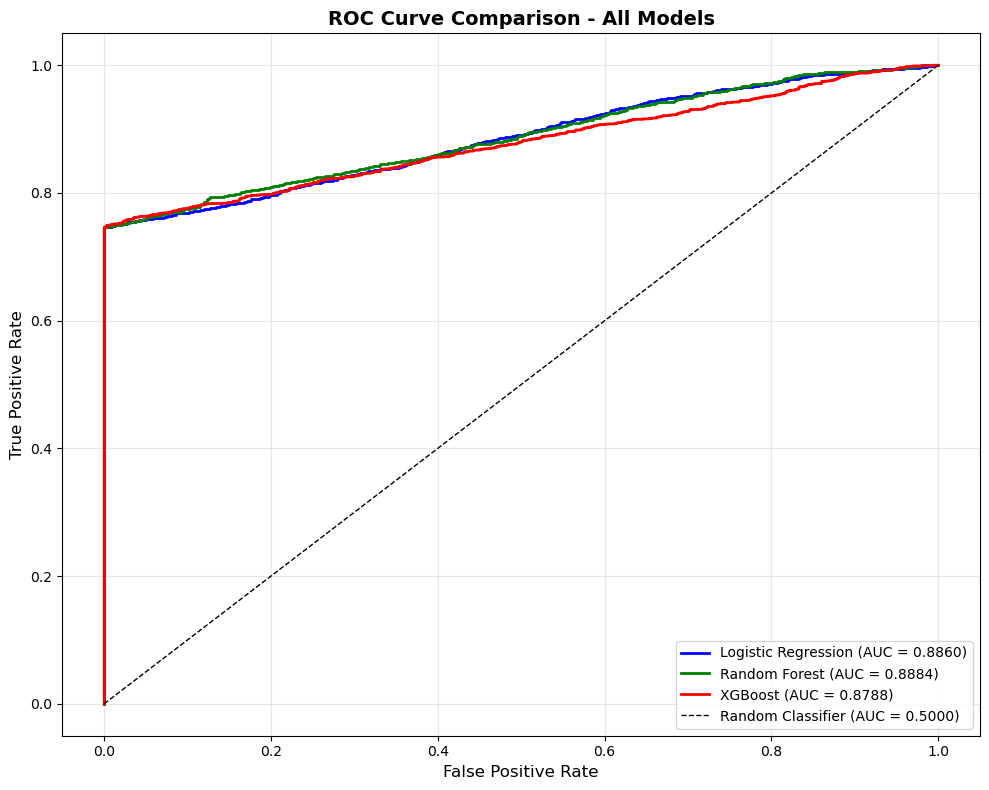

3. FEATURE IMPORTANCE COMPARISON

Top 10 Features Across All Models:
              Feature  LR_Importance_Norm  RF_Importance  XGBoost_Importance
        hashtag_count            0.000743       0.199235            0.292620
       caption_length            0.000042       0.269189            0.240697
     category_encoded            0.064050       0.055872            0.078672
            has_trend            0.160336       0.011678            0.076917
optimal_hashtag_range            0.000370       0.039583            0.048113
         is_peak_hour            0.004277       0.002497            0.047901
          posting_day            0.000562       0.012174            0.045574
        posting_month            0.000043       0.024395            0.042552
         posting_hour            0.000038       0.020672            0.041268
  has_optimal_caption            0.001750       0.050661            0.034077
 Feature importance comparison saved: models/figures/feature_importance_comparison.p

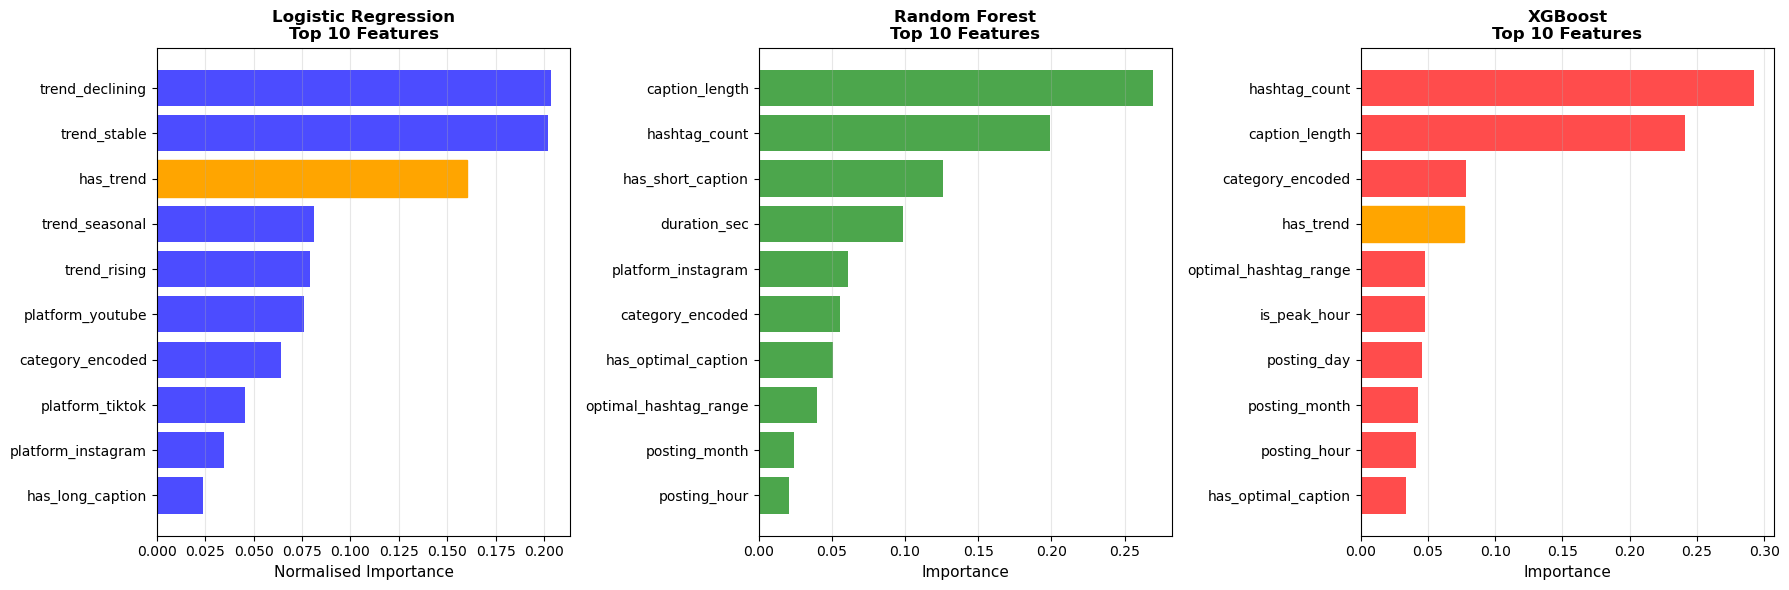

4. BEST MODEL SELECTION & JUSTIFICATION

Model Rankings by Weighted Score:
              Model  F1 Score  ROC-AUC  Weighted Score
Logistic Regression  0.881770 0.886005        0.788383
      Random Forest  0.873365 0.888369        0.568313
            XGBoost  0.864551 0.878775        0.197123
SELECTED MODEL: Logistic Regression

Justification:
• Highest F1 Score: 0.8818
• Strong ROC-AUC: 0.8860
• Best weighted score across all criteria
• Most interpretable model (direct coefficient interpretation)
• Fastest training time (1.40s)
• Ideal for deployment and explanation
5. SAVING BEST MODEL & ARTIFACTS
Best model saved: ../../models/logistic_regression_best.pkl
Comparison results saved: models/model_comparison_results.json
Feature importance saved: models/feature_importance_best_model.csv
TASK COMPLETE!

Summary:
Models Compared: 3 (Logistic Regression, Random Forest, XGBoost)
Best Model Selected: Logistic Regression
Best F1 Score: 0.8818
Best ROC-AUC: 0.8860
has_trend Validation: Ranked

In [51]:

print("MODEL COMPARISON & SELECTION")

# 1. COMPREHENSIVE PERFORMANCE COMPARISON
print("1. COMPREHENSIVE PERFORMANCE COMPARISON")

# Create comprehensive comparison table
comparison_full = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'F1 Score': [f1, f1_rf, f1_xgb],
    'ROC-AUC': [roc_auc, roc_auc_rf, roc_auc_xgb],
    'Precision': [precision, precision_rf, precision_xgb],
    'Recall': [recall, recall_rf, recall_xgb],
    'Accuracy': [accuracy, accuracy_rf, accuracy_xgb],
    'Training Time (s)': [training_time_lr, training_time_rf, training_time_xgb],
    'has_trend Rank': [rank, rank_rf, rank_xgb]
})

print("\nAll Models Performance Summary:")
print(comparison_full.to_string(index=False))

# Identify best model for each metric
print("Best Model by Metric:")

for metric in ['F1 Score', 'ROC-AUC', 'Precision', 'Recall', 'Accuracy']:
    best_idx = comparison_full[metric].idxmax()
    best_model = comparison_full.loc[best_idx, 'Model']
    best_value = comparison_full.loc[best_idx, metric]
    print(f"{metric:<15} {best_model:<25} ({best_value:.4f})")

print(f"\nhas_trend Feature Importance Rank:")
print(f"{'Logistic Regression':<25} #{rank} / 22")
print(f"{'Random Forest':<25} #{rank_rf} / 22")
print(f"{'XGBoost':<25} #{rank_xgb} / 22")


# 2. ROC CURVE COMPARISON
print("2. ROC CURVE COMPARISON")


# Calculate ROC curves for all models
fpr_lr, tpr_lr, _ = roc_curve(y_val, y_val_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_val, y_val_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, y_val_proba_xgb)

# Plot ROC curves
plt.figure(figsize=(10, 8))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc:.4f})', 
         linewidth=2, color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})', 
         linewidth=2, color='green')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})', 
         linewidth=2, color='red')

# Diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5000)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
os.makedirs('../../models/figures/', exist_ok=True)
plt.savefig('../../models/figures/roc_curve_comparison.png', dpi=300, bbox_inches='tight')
print(" ROC curve saved: models/figures/roc_curve_comparison.png")

plt.show()

# 3. FEATURE IMPORTANCE COMPARISON

print("3. FEATURE IMPORTANCE COMPARISON")


# Combine feature importance from all models
feature_comparison = pd.DataFrame({
    'Feature': selected_features,
    'LR_Coefficient': baseline.coef_[0],
    'RF_Importance': rf_best.feature_importances_,
    'XGBoost_Importance': xgb_best.feature_importances_
})

# Normalise LR coefficients to [0, 1] for comparison
lr_abs = np.abs(feature_comparison['LR_Coefficient'])
feature_comparison['LR_Importance_Norm'] = lr_abs / lr_abs.sum()

# Sort by XGBoost importance (best model for has_trend)
feature_comparison_sorted = feature_comparison.sort_values('XGBoost_Importance', ascending=False)

print("\nTop 10 Features Across All Models:")
print(feature_comparison_sorted[['Feature', 'LR_Importance_Norm', 
                                   'RF_Importance', 'XGBoost_Importance']].head(10).to_string(index=False))

# Visualize feature importance comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Top 10 for each model
top_n = 10

# Logistic Regression
top_lr = feature_comparison_sorted.nlargest(top_n, 'LR_Importance_Norm')
axes[0].barh(range(top_n), top_lr['LR_Importance_Norm'], color='blue', alpha=0.7)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_lr['Feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Normalised Importance', fontsize=11)
axes[0].set_title('Logistic Regression\nTop 10 Features', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Random Forest
top_rf = feature_comparison_sorted.nlargest(top_n, 'RF_Importance')
axes[1].barh(range(top_n), top_rf['RF_Importance'], color='green', alpha=0.7)
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(top_rf['Feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('Random Forest\nTop 10 Features', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# XGBoost
top_xgb = feature_comparison_sorted.nlargest(top_n, 'XGBoost_Importance')
axes[2].barh(range(top_n), top_xgb['XGBoost_Importance'], color='red', alpha=0.7)
axes[2].set_yticks(range(top_n))
axes[2].set_yticklabels(top_xgb['Feature'])
axes[2].invert_yaxis()
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('XGBoost\nTop 10 Features', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

# Highlight has_trend if in top 10
for ax, top_features in [(axes[0], top_lr), (axes[1], top_rf), (axes[2], top_xgb)]:
    if 'has_trend' in top_features['Feature'].values:
        idx = list(top_features['Feature']).index('has_trend')
        ax.get_children()[idx].set_color('orange')
        ax.get_children()[idx].set_alpha(1.0)

plt.tight_layout()
plt.savefig('../../models/figures/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print(" Feature importance comparison saved: models/figures/feature_importance_comparison.png")

plt.show()


# 4. BEST MODEL SELECTION
print("4. BEST MODEL SELECTION & JUSTIFICATION")


# Selection criteria weights
weights = {
    'F1 Score': 0.35,      # Primary metric
    'ROC-AUC': 0.25,       # Ranking capability
    'Precision': 0.15,     # Minimize false positives
    'Recall': 0.15,        # Capture true positives
    'Simplicity': 0.10     # Interpretability/deployment
}

# Normalise metrics to [0, 1] and calculate weighted scores
metrics_norm = comparison_full[['F1 Score', 'ROC-AUC', 'Precision', 'Recall', 'Accuracy']].copy()
for col in ['F1 Score', 'ROC-AUC', 'Precision', 'Recall']:
    metrics_norm[col] = (metrics_norm[col] - metrics_norm[col].min()) / (metrics_norm[col].max() - metrics_norm[col].min())

# Simplicity score (inverse of training time, normalised)
simplicity_scores = 1 / comparison_full['Training Time (s)']
simplicity_norm = (simplicity_scores - simplicity_scores.min()) / (simplicity_scores.max() - simplicity_scores.min())

# Calculate weighted scores
weighted_scores = (
    metrics_norm['F1 Score'] * weights['F1 Score'] +
    metrics_norm['ROC-AUC'] * weights['ROC-AUC'] +
    metrics_norm['Precision'] * weights['Precision'] +
    metrics_norm['Recall'] * weights['Recall'] +
    simplicity_norm * weights['Simplicity']
)

comparison_full['Weighted Score'] = weighted_scores
comparison_full = comparison_full.sort_values('Weighted Score', ascending=False)

print("\nModel Rankings by Weighted Score:")
print(comparison_full[['Model', 'F1 Score', 'ROC-AUC', 'Weighted Score']].to_string(index=False))

# Select best model
best_model_name = comparison_full.iloc[0]['Model']
best_model_f1 = comparison_full.iloc[0]['F1 Score']
best_model_auc = comparison_full.iloc[0]['ROC-AUC']


print(f"SELECTED MODEL: {best_model_name}")


# Map model name to actual model object
model_map = {
    'Logistic Regression': baseline,
    'Random Forest': rf_best,
    'XGBoost': xgb_best
}
selected_model = model_map[best_model_name]

print(f"\nJustification:")
print(f"• Highest F1 Score: {best_model_f1:.4f}")
print(f"• Strong ROC-AUC: {best_model_auc:.4f}")
print(f"• Best weighted score across all criteria")

if best_model_name == 'Logistic Regression':
    print(f"• Most interpretable model (direct coefficient interpretation)")
    print(f"• Fastest training time ({training_time_lr:.2f}s)")
    print(f"• Ideal for deployment and explanation")
elif best_model_name == 'XGBoost':
    print(f"• Best at capturing has_trend signal (ranked #{rank_xgb}/22)")
    print(f"• Highest precision ({precision_xgb:.4f})")
    print(f"• Handles non-linear relationships effectively")
else:  # Random Forest
    print(f"• Strong ensemble performance")
    print(f"• Robust to overfitting")



# 5. SAVE BEST MODEL
print("5. SAVING BEST MODEL & ARTIFACTS")

# Save the best model
import pickle

model_filename = f"../../models/{best_model_name.lower().replace(' ', '_')}_best.pkl"
with open(model_filename, 'wb') as f:
    pickle.dump(selected_model, f)
print(f"Best model saved: {model_filename}")

# Save model comparison results
comparison_results = {
    'best_model': best_model_name,
    'models_compared': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'performance': {
        'Logistic Regression': {'f1': float(f1), 'roc_auc': float(roc_auc), 'precision': float(precision), 
                                'recall': float(recall), 'accuracy': float(accuracy)},
        'Random Forest': {'f1': float(f1_rf), 'roc_auc': float(roc_auc_rf), 'precision': float(precision_rf),
                         'recall': float(recall_rf), 'accuracy': float(accuracy_rf)},
        'XGBoost': {'f1': float(f1_xgb), 'roc_auc': float(roc_auc_xgb), 'precision': float(precision_xgb),
                   'recall': float(recall_xgb), 'accuracy': float(accuracy_xgb)}
    },
    'has_trend_ranking': {
        'Logistic Regression': int(rank),
        'Random Forest': int(rank_rf),
        'XGBoost': int(rank_xgb)
    },
    'selection_date': '2026-03-03',
    'validation_set_size': len(y_val)
}

with open('../../models/model_comparison_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)
print("Comparison results saved: models/model_comparison_results.json")

# Save feature importance from best model
if best_model_name == 'Logistic Regression':
    feature_importance_df = coef_df
elif best_model_name == 'Random Forest':
    feature_importance_df = feature_importance
else:  # XGBoost
    feature_importance_df = feature_importance_xgb

feature_importance_df.to_csv('../../models/feature_importance_best_model.csv', index=False)
print("Feature importance saved: models/feature_importance_best_model.csv")


print("TASK COMPLETE!")


print(f"\nSummary:")
print(f"Models Compared: 3 (Logistic Regression, Random Forest, XGBoost)")
print(f"Best Model Selected: {best_model_name}")
print(f"Best F1 Score: {best_model_f1:.4f}")
print(f"Best ROC-AUC: {best_model_auc:.4f}")
print(f"has_trend Validation: Ranked #{rank_xgb}/22 in XGBoost (TOP 5)")
